In the file **wpb_votes_list_2019.csv** you will find data about the votes within the Wroclaw Citizens' Budget, downloaded from the page [Wrocław Open Data](https://www.wroclaw.pl/open-data/dataset/wroclawski-budzet-obywatelski-glosowanie).

Read this data and filter it to get the following series:
1. Women under the age of 100
2. Men under the age of 100

Next, draw a cumulative plot showing how many people of a given age voted (broken down by gender).

>Hint: To generate the plot correctly, you need to ensure that both series are of the same length. To do so, use the `reindex` method with the `fill_value` option:
> `s_reindexed = s.reindex(range(0, 100), fill_value=0)`


After creating the plot, generate a table that displays this data below it. The table with the contents of the cells and the table with the description of the rows, should be generated using a loop:
```
cells = []
cellLabels = []
for i in range(0,100):
    cells.append([f'Number of female voters aged f{i}', f'Number of female voters aged f{i}'])
    cellLabels.append(f'{i}')
```
Of course, instead of the captions, the corresponding values should be shown.

Review the options in the [documentation](https://matplotlib.org/stable/api/table_api.html#matplotlib.table.Table.codes) – what parameters can be used to make the table more readable?

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1 ucitavanje podataka i provera podataka

df = pd.read_csv('../01_Data for plots/wpb_votes_list_2019.csv')

df

,No,Date,Age,Sex,Post_Code,Source,Local,General
0,1,"9:01:21, 20-09-2019",33,F,54-117,I,256,132
1,2,"9:01:32, 20-09-2019",38,F,54-131,I,323,255
2,3,"9:02:28, 20-09-2019",32,F,54-107,I,256,132
3,4,"9:02:44, 20-09-2019",36,M,53-339,I,4,5
4,5,"9:02:51, 20-09-2019",31,M,50-231,I,108,120
...,...,...,...,...,...,...,...,...
83006,83007,"10:33:31, 08-10-2019",75,F,50-236,P,214,0
83007,83008,"10:34:03, 08-10-2019",73,F,50-262,P,214,0
83008,83009,"10:34:35, 08-10-2019",63,F,50-326,P,214,0
83009,83010,"10:35:21, 08-10-2019",43,F,51-114,P,434,3


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83011 entries, 0 to 83010
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   No         83011 non-null  int64 
 1   Date       83011 non-null  object
 2   Age        83011 non-null  int64 
 3   Sex        83011 non-null  object
 4   Post_Code  83009 non-null  object
 5   Source     83011 non-null  object
 6   Local      83011 non-null  int64 
 7   General    83011 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 5.1+ MB


In [35]:
df.shape

(83011, 8)

In [36]:
df.describe()

,No,Age,Local,General
count,83011.000000,83011.000000,83011.000000,83011.000000
mean,41506.000000,34.631025,203.413403,169.867548
std,23963.355935,18.247531,135.225674,134.173157
min,1.000000,0.000000,0.000000,0.000000
25%,20753.500000,25.000000,88.000000,18.000000
50%,41506.000000,34.000000,215.000000,151.000000
75%,62258.500000,43.000000,309.000000,275.000000
max,83011.000000,175.000000,447.000000,438.000000


In [37]:
# 2 Filtriramo da zadovoljimo uslov zadatka (Age <100) i kreiramo 2 nova df kako bi grupisali samo muskarce i samo zene

df_women = df.loc[
    (df["Sex"] == "F")&
    (df["Age"] <100)
]
df_man = df.loc[
    (df["Sex"] == "M")&
    (df["Age"] <=100)
]
df_women.describe()


,No,Age,Local,General
count,45809.000000,45809.000000,45809.000000,45809.000000
mean,41082.119125,35.624724,204.419394,170.976817
std,23975.722130,18.298960,135.084169,134.617937
min,1.000000,0.000000,0.000000,0.000000
25%,20317.000000,26.000000,95.000000,21.000000
50%,40807.000000,35.000000,215.000000,151.000000
75%,61875.000000,44.000000,309.000000,275.000000
max,83011.000000,99.000000,447.000000,438.000000


In [38]:
# 3 Grupisemo glasace ("F" i "M") po godinama

s_women = df_women.groupby("Age").size()
s_man = df_man.groupby("Age").size()
print(s_women, s_man)
print("--------1-----------")


Age
0     379
1     447
2     463
3     552
4     535
     ... 
95      9
96      8
97      3
98      1
99      3
Length: 100, dtype: int64 Age
0     401
1     471
2     513
3     579
4     578
     ... 
94      9
95      4
96      3
97      1
98      1
Length: 99, dtype: int64
--------1-----------


In [40]:
# 4 Reindexiramo grupisane df da izbegnemo prazne vrednosti

s_women_reindex = s_women.reindex(range(0,100), fill_value=0) # preskocene vrednosti se popunjavaju sa 0
s_man_reindex = s_man.reindex(range(0,100), fill_value=0)



In [41]:
# 5 pravimo cumsum atribute

s_women_reindex_cumsum = s_women_reindex.cumsum()
s_man_reindex_cumsum = s_man_reindex.cumsum()

s_women_reindex_cumsum, s_man_reindex_cumsum


(Age
 0       379
 1       826
 2      1289
 3      1841
 4      2376
       ...  
 95    45794
 96    45802
 97    45805
 98    45806
 99    45809
 Length: 100, dtype: int64,
 Age
 0       401
 1       872
 2      1385
 3      1964
 4      2542
       ...  
 95    37186
 96    37189
 97    37190
 98    37191
 99    37191
 Length: 100, dtype: int64)

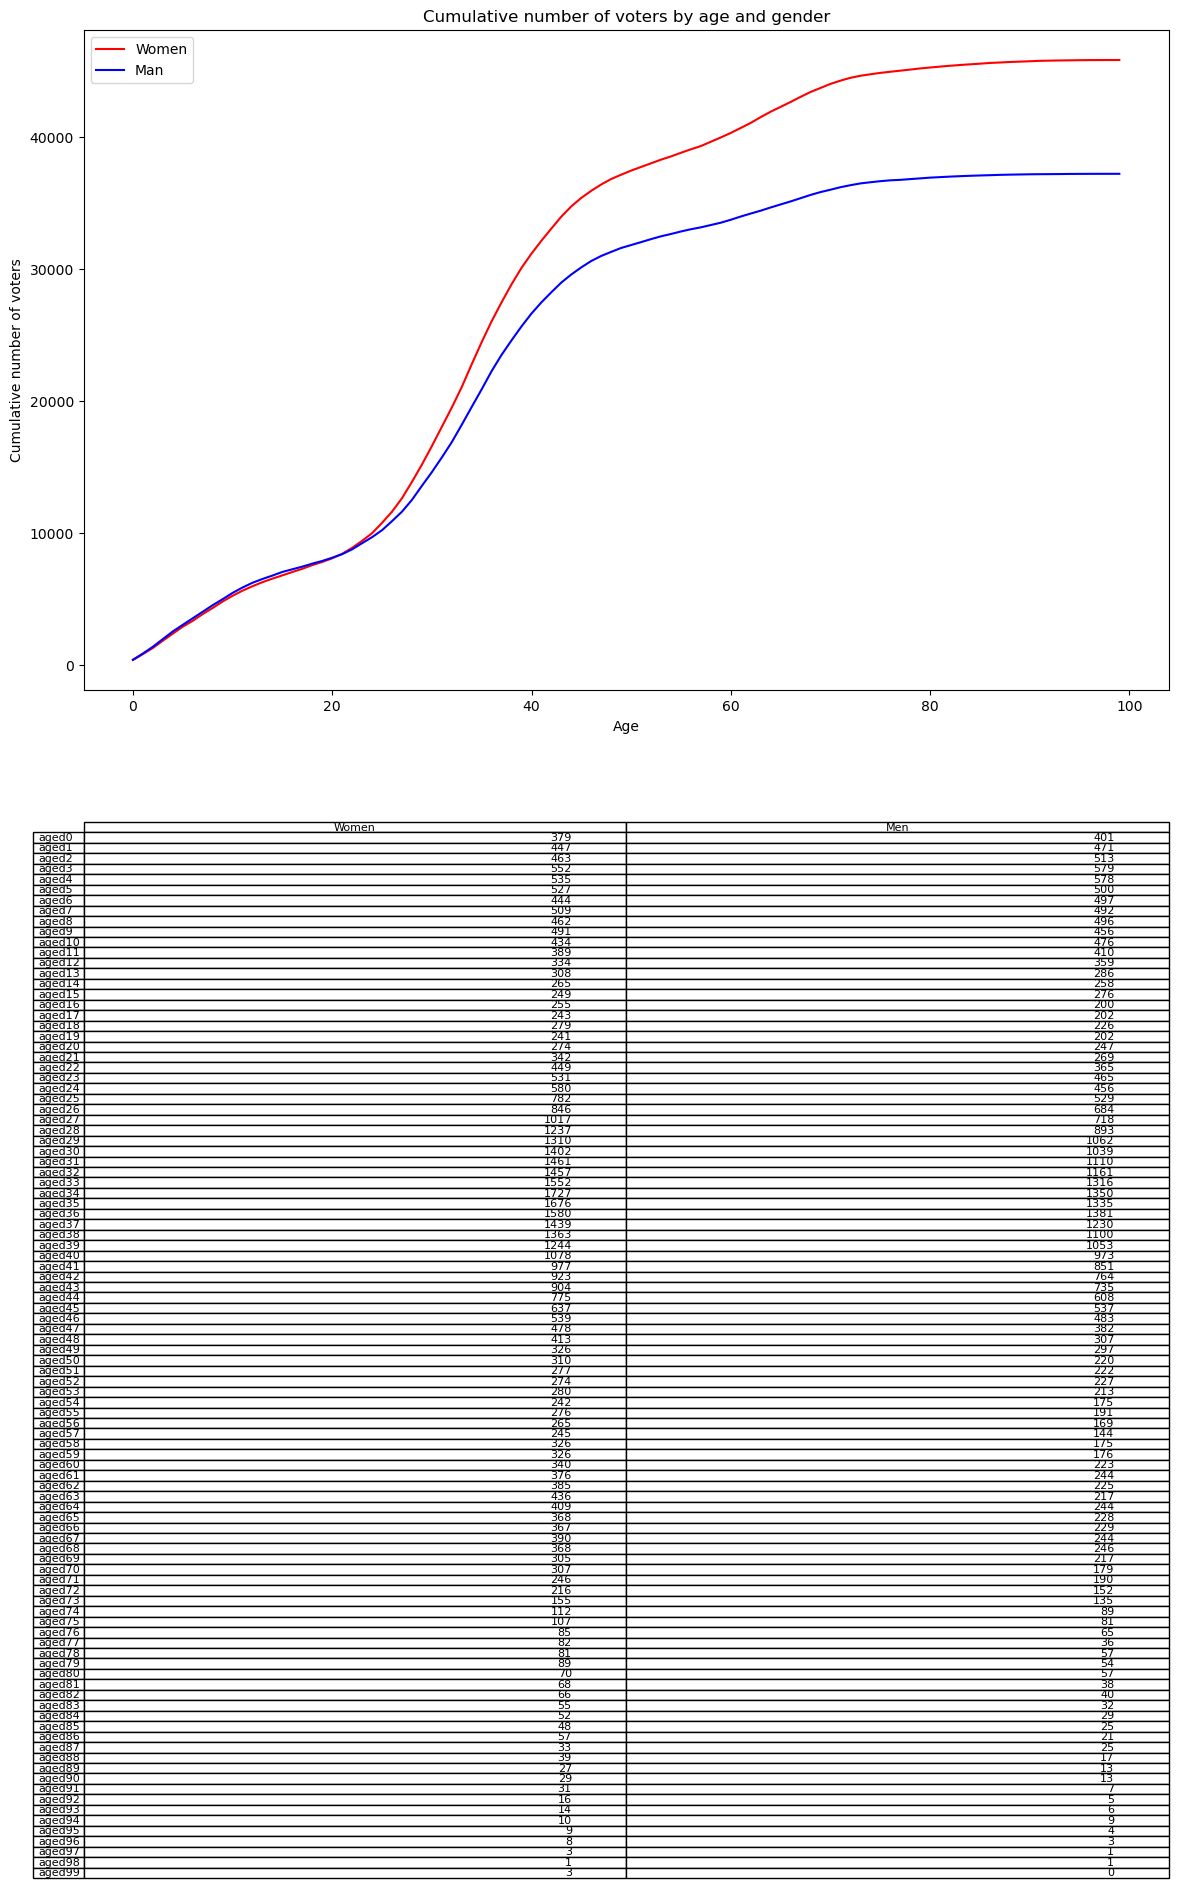

In [47]:
# 6 crtamo cumsum linechart sa tabelom

# Figura

fig, ax = plt.subplots(figsize=(14,20))

# Kumulativni grafikon

ax.plot(range(0,100), s_women_reindex_cumsum, 
        label="Women", color="red")
ax.plot(range(0,100), s_man_reindex_cumsum, 
        label="Man", color="blue")

ax.set_title("Cumulative number of voters by age and gender")
ax.set_xlabel("Age")
ax.set_ylabel("Cumulative number of voters")
ax.legend()

#----------------
# Generisanje tabele preko petlje
#----------------

cells = []
celllabels = []

for i in range (0,100):
    cells.append([
        s_women_reindex.iloc[i],
        s_man_reindex.iloc[i]
    ])
    celllabels.append(f'aged{i}')
table = plt.table(
    cellText=cells,
    rowLabels=celllabels,
    colLabels=["Women", "Men"],
    loc="bottom",
    bbox=[0, -1.8, 1, 1.6]
)

table.auto_set_font_size(False)
table.set_fontsize(8)

plt.subplots_adjust(bottom=0.55)
plt.show()


